<a href="https://colab.research.google.com/github/feridehmedovv200/OIBSIP/blob/main/DataAnalytics-Task1-EDARetailSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
cust = pd.read_excel('retail_sales_dataset.xlsx', sheet_name='Customers')
prod = pd.read_excel('retail_sales_dataset.xlsx', sheet_name='Products')
stores = pd.read_excel('retail_sales_dataset.xlsx', sheet_name='Stores')
tx = pd.read_excel('retail_sales_dataset.xlsx', sheet_name='Transactions')

In [5]:
df = tx.merge(cust, on='CustomerID', how='left') \
       .merge(prod, on='ProductID', how='left') \
       .merge(stores, on='StoreID', how='left')

In [6]:
df['GrossRevenue'] = df['Quantity'] * df['UnitPrice']
df['NetRevenue'] = df['GrossRevenue'] * (1 - df['Discount'])
df['TotalCost'] = df['Quantity'] * df['CostPrice']
df['Profit'] = df['NetRevenue'] - df['TotalCost']
df['Age'] = (df['Date'] - df['BirthDate']).dt.days // 365

In [7]:
print("=== Dataset Ölçüsü (Shape) ===")
print(df.shape)
print("\n=== Sütun Dtypes ===")
print(df.dtypes)
print("\n=== Boş Dəyərlərin Yoxlanılması (Null Check) ===")
print(df.isnull().sum())

=== Dataset Ölçüsü (Shape) ===
(5000, 27)

=== Sütun Dtypes ===
TransactionID            object
Date             datetime64[ns]
CustomerID               object
ProductID                object
StoreID                  object
Quantity                  int64
Discount                float64
PaymentMethod            object
FirstName                object
LastName                 object
Gender                   object
BirthDate        datetime64[ns]
City_x                   object
JoinDate         datetime64[ns]
ProductName              object
Category                 object
SubCategory              object
UnitPrice               float64
CostPrice               float64
StoreName                object
City_y                   object
Region                   object
GrossRevenue            float64
NetRevenue              float64
TotalCost               float64
Profit                  float64
Age                       int64
dtype: object

=== Boş Dəyərlərin Yoxlanılması (Null Check) ===
Transact

In [8]:
num_cols = ['Age', 'Quantity', 'Discount', 'UnitPrice', 'CostPrice', 'NetRevenue', 'Profit']

stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['mode'] = df[num_cols].mode().iloc[0]

In [9]:
stats_df = stats_df[['mean', 'median', 'mode', 'std', 'min', 'max']]
stats_df.columns = ['Mean', 'Median', 'Mode', 'Std Dev', 'Min', 'Max']
stats_df.round(2)

,Mean,Median,Mode,Std Dev,Min,Max
Age,43.44,44.00,64.00,15.43,16.00,70.00
Quantity,2.99,3.00,2.00,1.41,1.00,5.00
Discount,0.08,0.10,0.15,0.06,0.00,0.15
UnitPrice,1036.61,1193.09,1134.80,589.32,25.57,1952.65
CostPrice,702.00,794.80,675.10,426.69,15.28,1451.27
NetRevenue,2860.38,2156.12,4267.91,2265.96,21.73,9763.25
Profit,765.26,555.11,297.77,711.18,2.68,4372.60


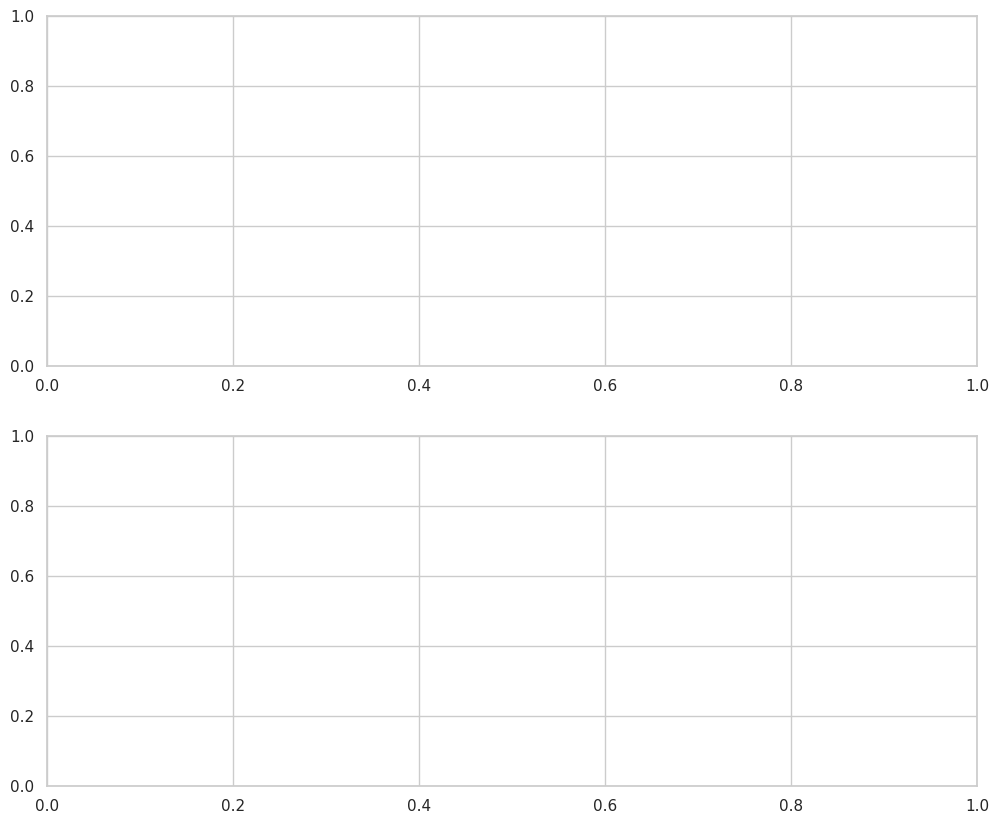

In [10]:
df['YearMonth'] = df['Date'].dt.to_period('M')
df['YearQuarter'] = df['Date'].dt.to_period('Q')

monthly_rev = df.groupby('YearMonth')['NetRevenue'].sum()
quarterly_rev = df.groupby('YearQuarter')['NetRevenue'].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

In [11]:
axes[0].plot(monthly_rev.index.astype(str), monthly_rev.values / 1000, marker='o', color='#1f77b4', linewidth=2)
axes[0].set_title('Aylıq Xalis Gəlir Trendi ($K)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Gəlir ($K)')
axes[0].tick_params(axis='x', rotation=45)

In [12]:
axes[1].plot(quarterly_rev.index.astype(str), quarterly_rev.values / 1000, marker='s', color='#ff7f0e', linewidth=2)
axes[1].set_title('Rüblük Xalis Gəlir Trendi ($K)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gəlir ($K)')

Text(4.444444444444473, 0.5, 'Gəlir ($K)')

In [13]:
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

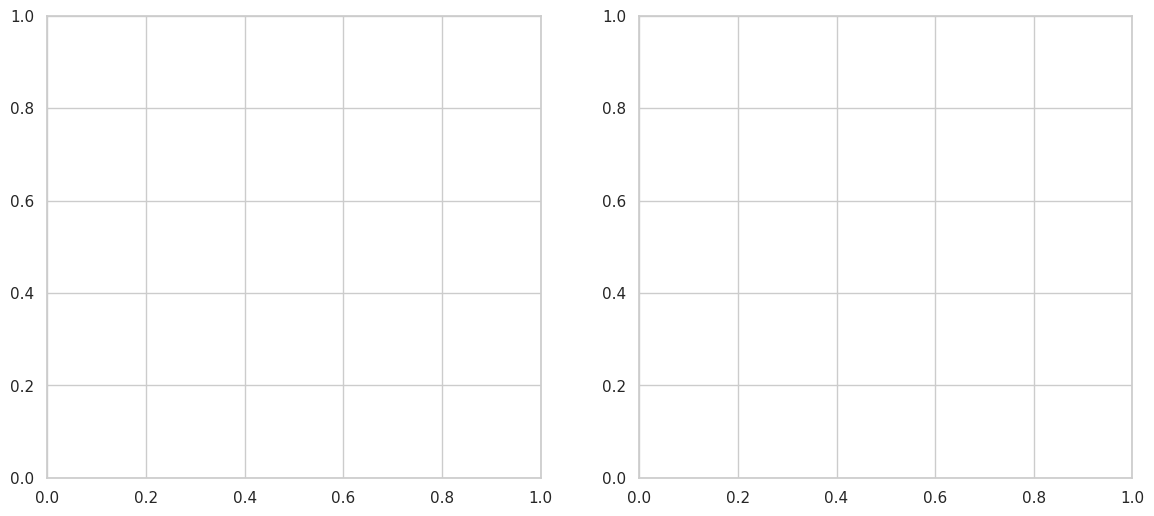

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

In [15]:
sns.histplot(df['Age'], bins=15, kde=True, ax=axes[0], color='#2ca02c')
axes[0].set_title('Müştərilərin Yaş Paylanması', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Əməliyyat Sayı')

Text(4.444444444444473, 0.5, 'Əməliyyat Sayı')

In [16]:
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=['Kişi (M)', 'Qadın (F)'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0.03,0))
axes[1].set_title('Müştərilərin Cinsiyyət Bölgüsü', fontsize=13, fontweight='bold')

Text(0.5, 1.0, 'Müştərilərin Cinsiyyət Bölgüsü')

In [17]:
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

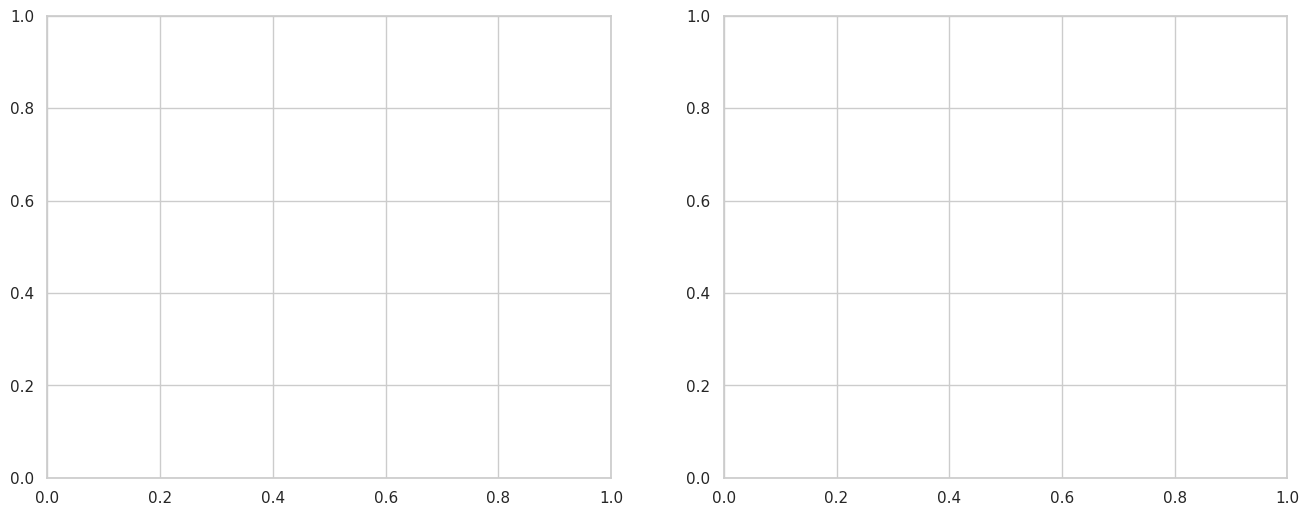

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

In [19]:
top_10_products = df.groupby('ProductName')['NetRevenue'].sum().nlargest(10).reset_index()
sns.barplot(data=top_10_products, x='NetRevenue', y='ProductName', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Satılan Məhsul (Xalis Gəlir üzrə)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Xalis Gəlir ($)')

Text(0.5, 4.444444444444445, 'Xalis Gəlir ($)')

In [20]:
cat_rev = df.groupby('Category')['NetRevenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_rev, x='Category', y='NetRevenue', palette='Set2', ax=axes[1])
axes[1].set_title('Kateqoriyalar Üzrə Ümumi Xalis Gəlir', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Xalis Gəlir ($)')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

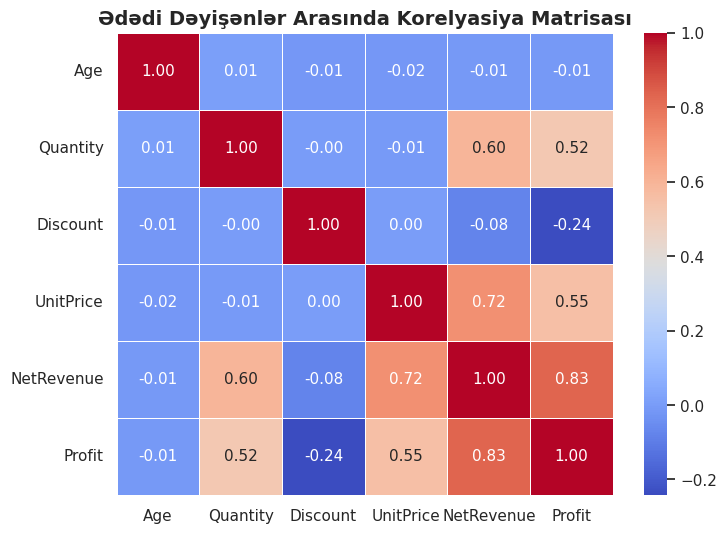

In [21]:
plt.figure(figsize=(8, 6))
corr_vars = df[['Age', 'Quantity', 'Discount', 'UnitPrice', 'NetRevenue', 'Profit']].corr()

sns.heatmap(corr_vars, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ədədi Dəyişənlər Arasında Korelyasiya Matrisası', fontsize=14, fontweight='bold')
plt.show()

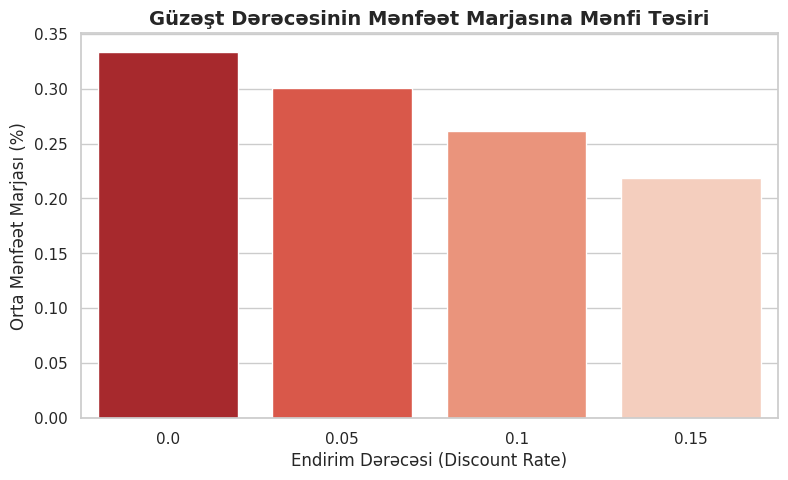

In [22]:
plt.figure(figsize=(9, 5))
df['ProfitMargin'] = df['Profit'] / df['NetRevenue']
discount_profit = df.groupby('Discount')['ProfitMargin'].mean().reset_index()

sns.barplot(data=discount_profit, x='Discount', y='ProfitMargin', palette='Reds_r')
plt.title('Güzəşt Dərəcəsinin Mənfəət Marjasına Mənfi Təsiri', fontsize=14, fontweight='bold')
plt.xlabel('Endirim Dərəcəsi (Discount Rate)')
plt.ylabel('Orta Mənfəət Marjası (%)')
plt.show()